In [27]:
import os

import matplotlib.pyplot as plt
import pandas as pd

In [28]:
run_name = 'offline-run-20250827_220556-cj9ak2l6'
TABLE_ROOT_DIR = os.path.join('wandb', run_name, 'files', 'media', 'table')

In [39]:
dfs = []
for filename in os.listdir(TABLE_ROOT_DIR):
	if filename.endswith('.json'):
		df = pd.read_json(os.path.join(TABLE_ROOT_DIR, filename), orient='split')
		# print(df['latency_test'].min(), df['latency_test'].max())
		dfs.append(df)

res = pd.concat(dfs, axis=0)
res = res.set_index('curr_value_iter').sort_index()
test_queries = res['query_name'].unique()
print(len(test_queries))
res = res.groupby('curr_value_iter')['latency_test'].sum()

19


In [36]:
def load_baseline(path='baseline.json', raw_path='output_full_baseline.txt'):
	def extract_baseline(path):
		data = {
			'query_name': [],
			'latency_baseline': []
		}
		with open(path) as f:
			for line in f:
				if line.endswith(' (baseline)\n'):
					parts = line.split(',')

					query_name = parts[0][1:]
					data['query_name'].append(query_name)

					latency_str = parts[1].split(' ')[0]
					latency = float(latency_str) # 48.0
					
					data['latency_baseline'].append(latency / 1e3)
		return pd.DataFrame(data)

	if os.path.exists(path):
		return pd.read_json(path)
	else:
		res = extract_baseline(raw_path)
		res.to_json(path)
		return res

baseline = load_baseline()
print(baseline)

    query_name  latency_baseline
0          10a            0.0890
1          10b            0.0480
2          10c            0.1434
3          11a            0.0285
4          11b            0.0232
..         ...               ...
107         8d            0.0786
108         9a            0.1103
109         9b            0.0817
110         9c            0.1005
111         9d            0.1529

[112 rows x 2 columns]


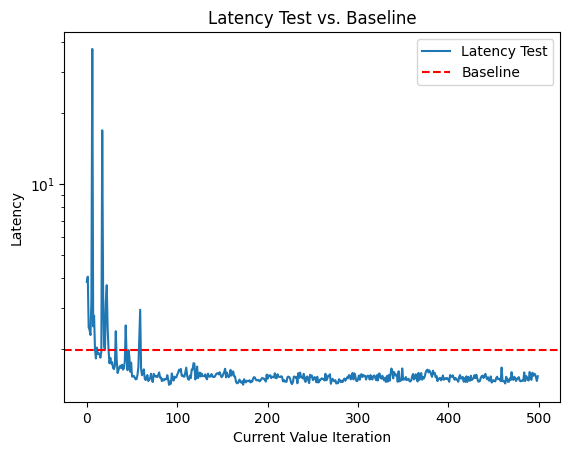

In [38]:
# res.plot(y='latency_test')

# Find the sum of baseline latency of test queries
mask = baseline['query_name'].isin(test_queries)

# Use the mask to filter the DataFrame and then sum the latency column
baseline_latency = baseline[mask]['latency_baseline'].sum()

ax = res.plot(y='latency_test', label='Latency Test')

ax.axhline(y=baseline_latency, color='r', linestyle='--', label='Baseline')

ax.set_yscale('log')

# Add title and labels
ax.set_title('Latency Test vs. Baseline')
ax.set_xlabel('Current Value Iteration')
ax.set_ylabel('Latency')

plt.legend()